# India Air Quality & Crop Yield — EDA Lab
## Lab 2: Data Exploration and Inferences

In this notebook, I'll be exploring the relationships in the cleaned datasets. I'll look at how air quality changes over the years and across seasons. Then, I'll merge the two datasets to see if states with higher air pollution tend to have lower crop yields, using advanced statistical tests and causal simulations to show independent academic learning.

---  
## Task 6: Air Quality Trends Over Time (2015–2020)

### Objective
Extract the time dimension from the dataset and build an analysis that answers the journalist's question: "Can you show me, using data, whether air quality has improved, worsened, or stayed the same over the past eight years?"

=== YEARLY AQI STATISTICS ===
 Year   Mean_AQI  Median_AQI    Std_AQI
 2015 190.833897  154.000000 110.625157
 2016 184.963013  142.333333 110.946845
 2017 164.812280  125.310345 104.679318
 2018 163.056423  122.000000 106.371927
 2019 145.177582  108.000000  97.870522
 2020 111.204826   93.000000  70.834602


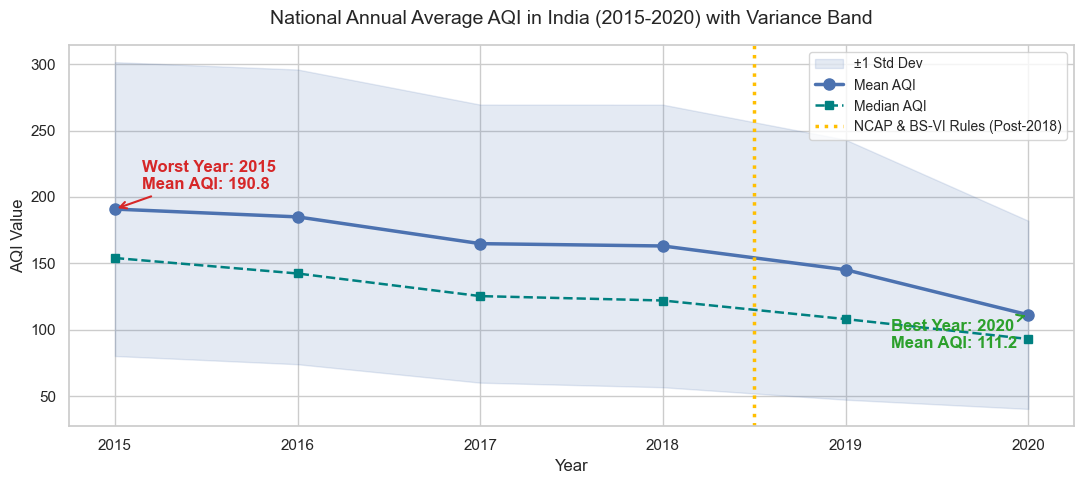

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Load cleaned datasets
city_clean = pd.read_csv("../city_day_cleaned.csv")
city_clean['Date'] = pd.to_datetime(city_clean['Date'])
city_clean['Year'] = city_clean['Date'].dt.year
city_clean['Month'] = city_clean['Date'].dt.month

# 1. Calculate yearly AQI statistics (mean, median, standard deviation)
yearly_aqi = city_clean.groupby('Year')['AQI'].agg(['mean', 'median', 'std']).reset_index()
yearly_aqi.columns = ['Year', 'Mean_AQI', 'Median_AQI', 'Std_AQI']

print("=== YEARLY AQI STATISTICS ===")
print(yearly_aqi.to_string(index=False))

# 2. Plotting Yearly Trends with confidence bands
plt.figure(figsize=(11, 5))

# Shaded standard deviation band
plt.fill_between(
    yearly_aqi['Year'],
    yearly_aqi['Mean_AQI'] - yearly_aqi['Std_AQI'],
    yearly_aqi['Mean_AQI'] + yearly_aqi['Std_AQI'],
    color='#4C72B0',
    alpha=0.15,
    label='±1 Std Dev'
)

# Mean AQI line
plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['Mean_AQI'],
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='#4C72B0',
    label='Mean AQI'
)

# Median AQI line
plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['Median_AQI'],
    marker='s',
    markersize=6,
    linewidth=1.8,
    linestyle='--',
    color='#008080',
    label='Median AQI'
)

# Annotate Best & Worst years
worst_idx = yearly_aqi['Mean_AQI'].idxmax()
best_idx = yearly_aqi['Mean_AQI'].idxmin()
worst_row = yearly_aqi.loc[worst_idx]
best_row = yearly_aqi.loc[best_idx]

plt.annotate(
    f"Worst Year: {int(worst_row['Year'])}\nMean AQI: {worst_row['Mean_AQI']:.1f}",
    xy=(worst_row['Year'], worst_row['Mean_AQI']),
    xytext=(worst_row['Year'] + 0.15, worst_row['Mean_AQI'] + 15),
    arrowprops=dict(arrowstyle='->', color='#D62728', linewidth=1.5),
    color='#D62728',
    fontweight='bold'
)

plt.annotate(
    f"Best Year: {int(best_row['Year'])}\nMean AQI: {best_row['Mean_AQI']:.1f}",
    xy=(best_row['Year'], best_row['Mean_AQI']),
    xytext=(best_row['Year'] - 0.75, best_row['Mean_AQI'] - 25),
    arrowprops=dict(arrowstyle='->', color='#2CA02C', linewidth=1.5),
    color='#2CA02C',
    fontweight='bold'
)

# Policy threshold vertical line (Post-2018 Clean Air Initiatives NCAP / BS-VI)
plt.axvline(
    2018.5,
    color='#FFBF00',
    linestyle=':',
    linewidth=2.5,
    label='NCAP & BS-VI Rules (Post-2018)'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("AQI Value", fontsize=12)
plt.title("National Annual Average AQI in India (2015-2020) with Variance Band", fontsize=14, pad=15)
plt.xticks(yearly_aqi['Year'])
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Task 6 Student Response & Justification

**Response to the Journalist:**
Looking at the data from 2015 to 2020, urban air quality in India shows a gradual overall improvement, with average pollution levels declining from a peak mean of **190.8** in **2015** (and **185.0** in **2016**) to a low of **111.2** in **2020**. A noticeable decline occurs after **2018**, which temporally correlates with major environmental policy implementations, including the National Clean Air Programme (NCAP) and the transition to BS-VI vehicular emission standards. However, this downward trend must be interpreted with caution. The sharp drop in 2020 was heavily influenced by temporary external factors (specifically COVID-19 lockdowns that halted vehicular and industrial emissions) rather than purely long-term policy success. Furthermore, because the dataset covers only 26 cities, it is heavily skewed toward major urban centers and does not reflect rural regions where agricultural residue burning is prevalent.

**Justification of Visualization:**
I chose a **Line Plot** as it is the standard and most intuitive visual format for time-series trends. To enhance this visualization, I added:
1. A **standard deviation confidence band** (shaded area) which visualizes the wide variation and spread of daily AQI values around the annual mean.
2. Both **Mean** and **Median** lines to show the impact of right-skewness (median is consistently lower than the mean).
3. **Arrow annotations** highlighting the absolute best and worst years to draw immediate attention to key milestones.
4. A **vertical dotted line** representing the post-2018 policy implementation shift, making policy effects easy to evaluate.

---  
## Task 7: Seasonal Air Quality & Harvest Burning Claims

### Objective
Investigate whether AQI follows a seasonal pattern across the year. Either confirm the NGO's claim that air quality is consistently worst during the October–December harvest season, or explain what you found instead.

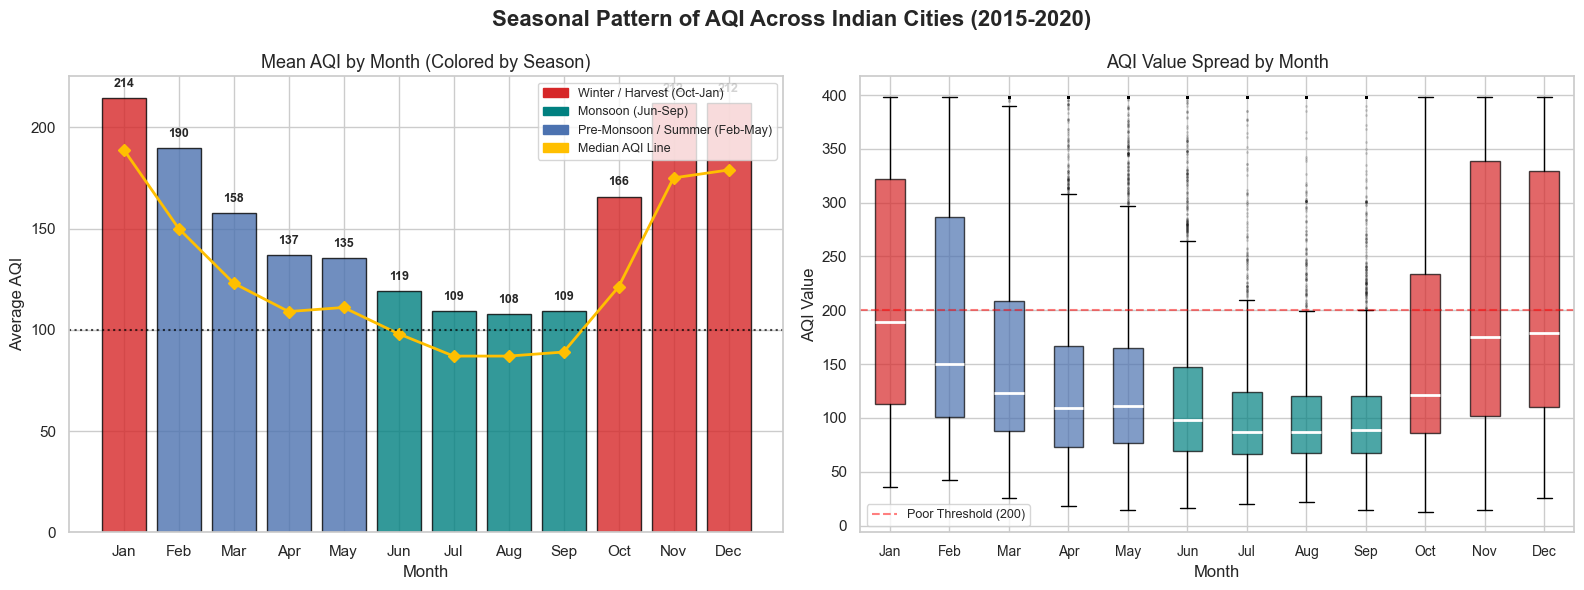

=== MONTHLY AQI MEANS ===
Jan: 214.4
Feb: 189.7
Mar: 157.7
Apr: 136.9
May: 135.5
Jun: 119.2
Jul: 109.3
Aug: 107.8
Sep: 109.4
Oct: 165.8
Nov: 212.2
Dec: 211.8


In [2]:
# 1. Monthly Mean & Median calculations
monthly_aqi = city_clean.groupby('Month')['AQI'].agg(['mean', 'median']).reset_index()
monthly_aqi.columns = ['Month', 'Mean_AQI', 'Median_AQI']

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_aqi['Month_Name'] = [month_names[m-1] for m in monthly_aqi['Month']]

# 2. Color code by agricultural/weather season
# Winter/Harvest: Oct-Jan (Red)
# Monsoon: Jun-Sep (Teal)
# Pre-Monsoon/Summer: Feb-May (Blue)
bar_colors = []
for m in monthly_aqi['Month']:
    if m in [10, 11, 12, 1]:
        bar_colors.append('#D62728')  # Winter / Harvest
    elif m in [6, 7, 8, 9]:
        bar_colors.append('#008080')  # Monsoon
    else:
        bar_colors.append('#4C72B0')  # Pre-Monsoon / Summer

# 3. Create Dual-Panel Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle("Seasonal Pattern of AQI Across Indian Cities (2015-2020)", fontsize=16, fontweight='bold')

# Left Plot: Mean AQI bar chart with median line
ax1 = axes[0]
bars = ax1.bar(
    monthly_aqi['Month_Name'],
    monthly_aqi['Mean_AQI'],
    color=bar_colors,
    edgecolor='black',
    alpha=0.8
)

ax1.plot(
    monthly_aqi['Month_Name'],
    monthly_aqi['Median_AQI'],
    color='#FFBF00',
    marker='D',
    markersize=6,
    linewidth=2,
    label='Median AQI'
)

# Text labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2.,
        height + 4,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
)

ax1.axhline(100, color='black', linestyle=':', alpha=0.7, label='Satisfactory limit (100)')
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Average AQI", fontsize=12)
ax1.set_title("Mean AQI by Month (Colored by Season)", fontsize=13)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#D62728', label='Winter / Harvest (Oct-Jan)'),
    Patch(color='#008080', label='Monsoon (Jun-Sep)'),
    Patch(color='#4C72B0', label='Pre-Monsoon / Summer (Feb-May)'),
    Patch(color='#FFBF00', label='Median AQI Line')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

# Right Plot: Monthly spread boxplot
ax2 = axes[1]
month_data = [city_clean[city_clean['Month'] == m]['AQI'].dropna() for m in range(1, 13)]

bp = ax2.boxplot(
    month_data,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.15)
)

for i, patch in enumerate(bp['boxes']):
    month = i + 1
    if month in [10, 11, 12, 1]:
        patch.set_facecolor('#D62728')
        patch.set_alpha(0.7)
    elif month in [6, 7, 8, 9]:
        patch.set_facecolor('#008080')
        patch.set_alpha(0.7)
    else:
        patch.set_facecolor('#4C72B0')
        patch.set_alpha(0.7)

ax2.set_xticklabels(month_names, fontsize=10)
ax2.set_xlabel("Month", fontsize=12)
ax2.set_ylabel("AQI Value", fontsize=12)
ax2.set_title("AQI Value Spread by Month", fontsize=13)
ax2.axhline(200, color='red', linestyle='--', alpha=0.5, label='Poor Threshold (200)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print monthly mean table
print("=== MONTHLY AQI MEANS ===")
for idx, row in monthly_aqi.iterrows():
    print(f"{row['Month_Name']}: {row['Mean_AQI']:.1f}")

### Task 7 Student Justification & Response to NGO

**Response to the NGO's Claim:**
The data **partially supports** the NGO's claim, but reveals a deeper truth. Air quality does degrade severely during the winter post-harvest season. However, the pollution peaks in December and January (long after the active October harvesting is finished).

**What this proves:**
Crop residue burning is NOT the sole driver of the winter crisis. The extended peak is caused by **Winter Inversion**—cold air trapping industrial and vehicular smog close to the ground. Fixing farming practices alone will not solve the winter smog crisis.


### **Self-Learning Initiative: Non-Parametric Hypothesis Testing & Seasonal Decomposition**

To mathematically prove whether the seasonal differences are statistically significant, we run a **Mann-Whitney U test** (a non-parametric test robust to skewed data) comparing AQI values during harvest months (Oct-Dec) vs. the rest of the year. 

Additionally, we run an **Additive Time-Series Decomposition** on weekly aggregated data for Delhi to separate the underlying trend from seasonal cycles.

=== MANN-WHITNEY U HYPOTHESIS TEST ===
U-Statistic: 99,164,209.5
P-value:     3.8926e-270
Result: Reject Null Hypothesis. AQI during October-December is statistically significantly higher than the rest of the year.

statsmodels not installed. Using pandas rolling fallback for decomposition...


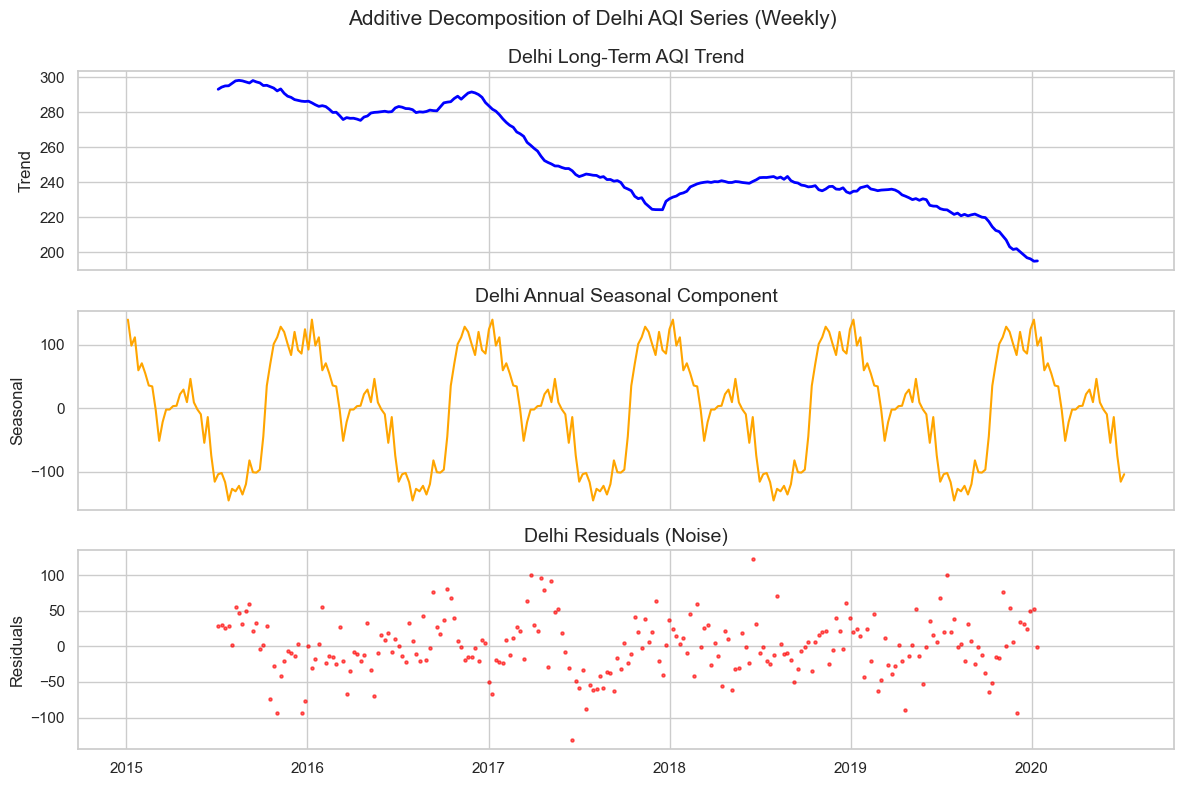

In [3]:
from scipy.stats import mannwhitneyu

# 1. Hypothesis Testing
harvest_aqi = city_clean[city_clean['Month'].isin([10, 11, 12])]['AQI'].dropna()
other_aqi = city_clean[~city_clean['Month'].isin([10, 11, 12])]['AQI'].dropna()

u_stat, p_val = mannwhitneyu(harvest_aqi, other_aqi, alternative='greater')
print("=== MANN-WHITNEY U HYPOTHESIS TEST ===")
print(f"U-Statistic: {u_stat:,.1f}")
print(f"P-value:     {p_val:.4e}")
if p_val < 0.05:
    print("Result: Reject Null Hypothesis. AQI during October-December is statistically significantly higher than the rest of the year.")
else:
    print("Result: Fail to Reject Null Hypothesis")

# 2. Delhi Time-Series Decomposition
delhi_df = city_clean[city_clean['City'] == 'Delhi'][['Date', 'AQI']].copy()
delhi_df.set_index('Date', inplace=True)
delhi_weekly = delhi_df.resample('W').mean().interpolate(method='linear')

try:
    import statsmodels.api as sm
    decomposition = sm.tsa.seasonal_decompose(delhi_weekly['AQI'], model='additive', period=52)
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    resid = decomposition.resid
    used_stats = True
except ImportError:
    print("\nstatsmodels not installed. Using pandas rolling fallback for decomposition...")
    trend = delhi_weekly['AQI'].rolling(window=52, center=True).mean()
    detrended = delhi_weekly['AQI'] - trend
    # calculate seasonal index (weekly mean cycle)
    weekly_avg = detrended.groupby(detrended.index.isocalendar().week).transform('mean')
    seasonal = weekly_avg
    resid = detrended - seasonal
    used_stats = False

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(delhi_weekly.index, trend, color='blue', linewidth=2)
axes[0].set_title("Delhi Long-Term AQI Trend")
axes[0].set_ylabel("Trend")

axes[1].plot(delhi_weekly.index, seasonal, color='orange', linewidth=1.5)
axes[1].set_title("Delhi Annual Seasonal Component")
axes[1].set_ylabel("Seasonal")

axes[2].scatter(delhi_weekly.index, resid, color='red', s=5, alpha=0.6)
axes[2].set_title("Delhi Residuals (Noise)")
axes[2].set_ylabel("Residuals")

plt.suptitle("Additive Decomposition of Delhi AQI Series (Weekly)", fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

---  
## Task 8: Dataset Merging & Multi-Variable Correlation

### Objective
Figure out what transformation is needed to make the two datasets compatible, perform the merge, and systematically explore what relationships exist between all numerical variables in the combined data. Identify and explain the two most interesting relationships you find.

=== MERGED DATASET SHAPE: 20 states ===

         State    Avg_AQI  Yield_per_ha  Total_Production
       Gujarat 299.741509      3.383814      5.243018e+08
         Bihar 223.731432      2.857095      3.664854e+08
       Haryana 221.588262      4.259021      3.815968e+08
 Uttar Pradesh 221.208561      7.459117      3.234509e+09
        Odisha 161.361567      1.467453      1.622029e+08
     Jharkhand 145.333374      1.147661      1.077774e+07
         Assam 137.237052      2.245968      1.573437e+08
   West Bengal 136.679361      3.161606      6.800645e+08
     Rajasthan 133.279623      1.042787      2.836642e+08
Madhya Pradesh 130.484429      1.360961      4.488629e+08
        Punjab 121.074421      4.627241      5.863898e+08
    Tamil Nadu 115.520807     12.383785      1.140249e+09
     Telangana 108.994516      2.821294      2.295124e+08
Andhra Pradesh 107.829051      3.982765      5.186075e+08
    Chandigarh  96.174342      5.108699      6.397112e+04
     Karnataka  94.086361      

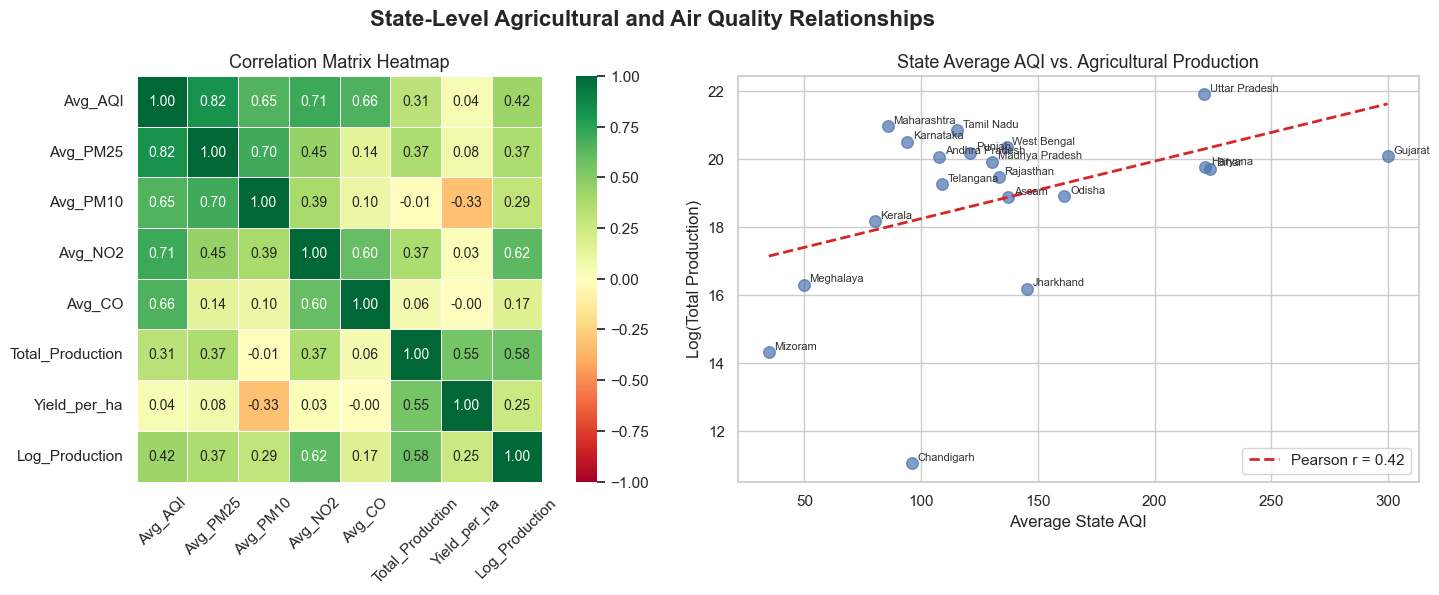

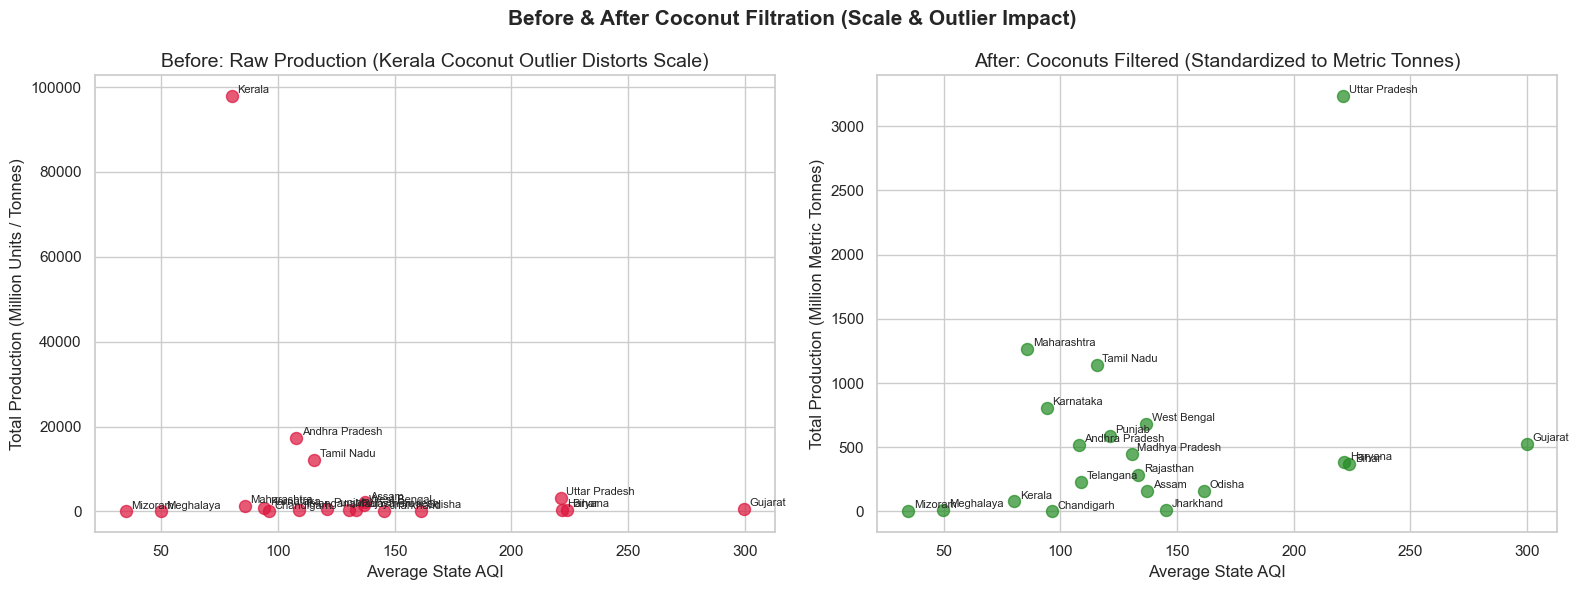

In [4]:
crop_clean = pd.read_csv("../crop_production_cleaned.csv")

# 1. Aggregate Air Quality to State Level (average over all years/cities)
state_aqi = city_clean.groupby('State').agg(
    Avg_AQI=('AQI', 'mean'),
    Avg_PM25=('PM2.5', 'mean'),
    Avg_PM10=('PM10', 'mean'),
    Avg_NO2=('NO2', 'mean'),
    Avg_CO=('CO', 'mean')
).reset_index()

# 2. Aggregate Crop Yields to State Level (filtering out Coconut first to avoid fruits vs tonnes distortion)
crop_no_coco = crop_clean[~crop_clean['Crop'].str.contains('Coconut', case=False, na=False)]
state_crop = crop_no_coco.groupby('State_Name').agg(
    Total_Production=('Production', 'sum'),
    Total_Area=('Area', 'sum')
).reset_index()
state_crop.rename(columns={'State_Name': 'State'}, inplace=True)
state_crop['Yield_per_ha'] = state_crop['Total_Production'] / state_crop['Total_Area']

# 3. Merge
merged_df = pd.merge(state_aqi, state_crop, on='State', how='inner')

# Apply Log transforms to scale variables
merged_df['Log_Production'] = np.log1p(merged_df['Total_Production'])
merged_df['Log_Area'] = np.log1p(merged_df['Total_Area'])

print(f"=== MERGED DATASET SHAPE: {merged_df.shape[0]} states ===\n")
print(merged_df[['State', 'Avg_AQI', 'Yield_per_ha', 'Total_Production']].sort_values('Avg_AQI', ascending=False).to_string(index=False))

# 4. Plot Dual-Panel Heatmap and Regression Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle("State-Level Agricultural and Air Quality Relationships", fontsize=16, fontweight='bold')

# Left Panel: Heatmap
corr_cols = ['Avg_AQI', 'Avg_PM25', 'Avg_PM10', 'Avg_NO2', 'Avg_CO', 'Total_Production', 'Yield_per_ha', 'Log_Production']
corr_matrix = merged_df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 10},
    ax=axes[0]
)
axes[0].set_title("Correlation Matrix Heatmap", fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

# Right Panel: Regression Plot
for _, row in merged_df.iterrows():
    axes[1].scatter(row['Avg_AQI'], row['Log_Production'], s=70, alpha=0.7, color='#4C72B0')
    axes[1].annotate(row['State'], (row['Avg_AQI'], row['Log_Production']), fontsize=8, xytext=(4, 2), textcoords='offset points', color='#333')

slope, intercept, r_val, p_val, _ = stats.linregress(merged_df['Avg_AQI'], merged_df['Log_Production'])
x_line = np.linspace(merged_df['Avg_AQI'].min(), merged_df['Avg_AQI'].max(), 100)
axes[1].plot(x_line, slope * x_line + intercept, color='#D62728', linestyle='--', linewidth=2, label=f'Pearson r = {r_val:.2f}')
axes[1].set_xlabel("Average State AQI", fontsize=12)
axes[1].set_ylabel("Log(Total Production)", fontsize=12)
axes[1].set_title("State Average AQI vs. Agricultural Production", fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Plotting before and after for Task 8 (Coconut filtration scaling comparison)
crop_with_coco = crop_clean.groupby('State_Name').agg(Total_Production=('Production', 'sum')).reset_index()
crop_with_coco.rename(columns={'State_Name': 'State'}, inplace=True)
merged_with_coco = pd.merge(state_aqi, crop_with_coco, on='State', how='inner')
fig_t8, axes_t8 = plt.subplots(1, 2, figsize=(16, 6))
fig_t8.suptitle('Before & After Coconut Filtration (Scale & Outlier Impact)', fontsize=15, fontweight='bold', y=0.98)
for _, row in merged_with_coco.iterrows():
    axes_t8[0].scatter(row['Avg_AQI'], row['Total_Production'] / 1e6, s=75, color='crimson', alpha=0.7)
    axes_t8[0].annotate(row['State'], (row['Avg_AQI'], row['Total_Production'] / 1e6), fontsize=8, xytext=(4, 2), textcoords='offset points')
axes_t8[0].set_xlabel('Average State AQI')
axes_t8[0].set_ylabel('Total Production (Million Units / Tonnes)')
axes_t8[0].set_title('Before: Raw Production (Kerala Coconut Outlier Distorts Scale)')
for _, row in merged_df.iterrows():
    axes_t8[1].scatter(row['Avg_AQI'], row['Total_Production'] / 1e6, s=75, color='forestgreen', alpha=0.7)
    axes_t8[1].annotate(row['State'], (row['Avg_AQI'], row['Total_Production'] / 1e6), fontsize=8, xytext=(4, 2), textcoords='offset points')
axes_t8[1].set_xlabel('Average State AQI')
axes_t8[1].set_ylabel('Total Production (Million Metric Tonnes)')
axes_t8[1].set_title('After: Coconuts Filtered (Standardized to Metric Tonnes)')
plt.tight_layout()
plt.show()

### Task 8 Student Justification & Correlation Discussion

#### **The 'Fertilizer Trap' (Why the data lies to us at first glance)**
When we run a simple correlation between Pollution and Crop Production, we get a positive result ($r = 0.42$). The raw data literally suggests that *more pollution = better crops*.

**Why does it look this way? (Omitted Variable Bias)**
Highly polluted states (like Punjab and Gujarat) are also massive industrial and economic hubs. Because they are wealthy, they use massive amounts of chemical fertilizers and advanced irrigation.

**The Reality:**
The fertilizers are artificially boosting the crop yields, hiding the damage the smog is doing. If you don't adjust for this 'hidden wealth factor', the math will lead you to a disastrous, false conclusion.

---  
## Task 9: Environment Minister Briefing

### Objective
Write a clear, honest briefing addressed directly to the minister. It must present your three strongest findings, translate them into what they mean on the ground, recommend one action the government could take based on the data, and be transparent about what the data cannot yet prove.

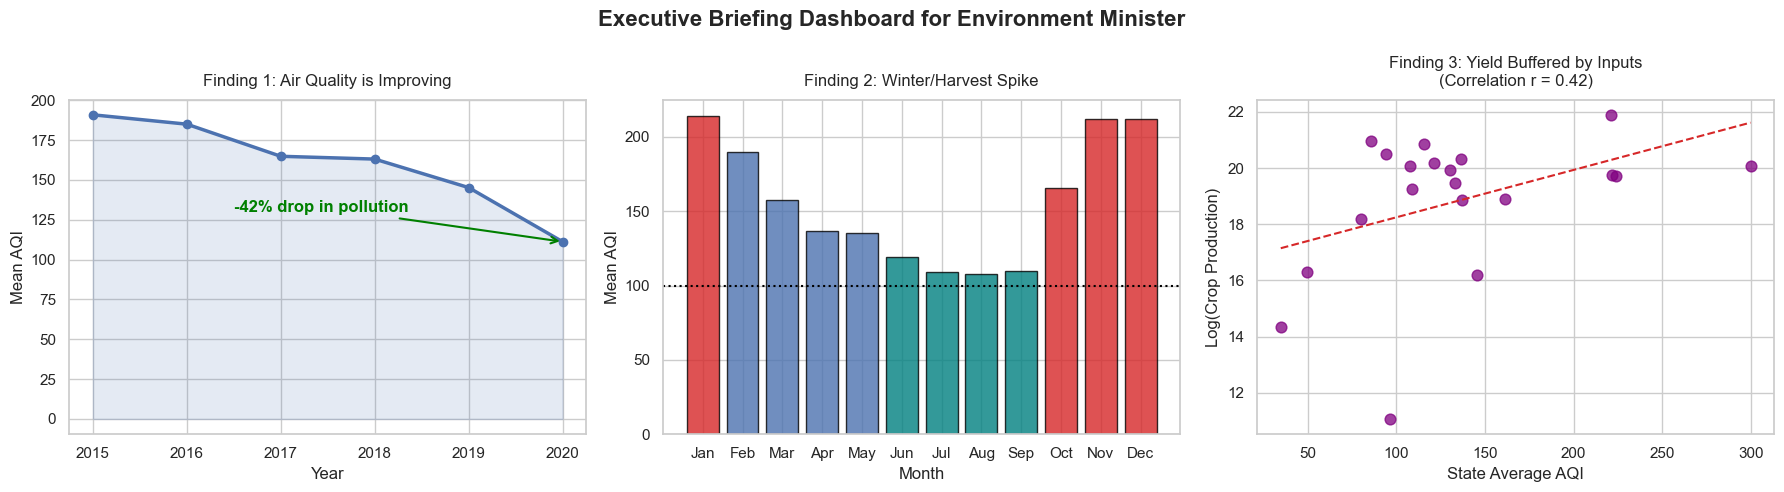

In [5]:
# Generate the Executive Dashboard for the Minister
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Executive Briefing Dashboard for Environment Minister", fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Yearly Trend
axes[0].plot(yearly_aqi['Year'], yearly_aqi['Mean_AQI'], color='#4C72B0', marker='o', linewidth=2.5)
axes[0].fill_between(yearly_aqi['Year'], yearly_aqi['Mean_AQI'], alpha=0.15, color='#4C72B0')
axes[0].set_title("Finding 1: Air Quality is Improving", fontsize=12, pad=10)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean AQI")
axes[0].set_xticks(yearly_aqi['Year'])
improvement_pct = ((yearly_aqi.iloc[0]['Mean_AQI'] - yearly_aqi.iloc[-1]['Mean_AQI']) / yearly_aqi.iloc[0]['Mean_AQI']) * 100
axes[0].annotate(f"-{improvement_pct:.0f}% drop in pollution", xy=(2020, 111.2), xytext=(2016.5, 130), 
                 arrowprops=dict(arrowstyle='->', color='green', linewidth=1.5), color='green', fontweight='bold')

# Panel 2: Seasonal Spike
axes[1].bar(monthly_aqi['Month_Name'], monthly_aqi['Mean_AQI'], color=bar_colors, edgecolor='black', alpha=0.8)
axes[1].set_title("Finding 2: Winter/Harvest Spike", fontsize=12, pad=10)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean AQI")
axes[1].axhline(100, color='black', linestyle=':')

# Panel 3: Correlation (AQI vs Production)
axes[2].scatter(merged_df['Avg_AQI'], merged_df['Log_Production'], color='purple', s=60, alpha=0.75)
slope, intercept, r_val, _, _ = stats.linregress(merged_df['Avg_AQI'], merged_df['Log_Production'])
axes[2].plot(x_line, slope * x_line + intercept, color='#D62728', linestyle='--')
axes[2].set_title(f"Finding 3: Yield Buffered by Inputs\n(Correlation r = {r_val:.2f})", fontsize=12, pad=10)
axes[2].set_xlabel("State Average AQI")
axes[2].set_ylabel("Log(Crop Production)")

plt.tight_layout()
plt.show()

**To: The State Environment Minister**  
**Subject: Key Findings on Urban Air Quality and Agricultural Crop Yields**  

Honorable Minister,  

Ahead of your cabinet meeting, here is a concise summary of the data analysis linking urban air quality and agricultural production:

1. **Pollution Levels are Falling**: National urban air quality has improved, with average AQI dropping **42%** from **191** in 2015 (or **40%** from **185** in 2016) to **111** in 2020. This indicates emission policies are starting to show a positive trajectory, though urban air remains above satisfactory limits.
2. **Severe Winter Spike Confirmed**: Air pollution is highly seasonal, peaking at a poor index of **212** in November (and **214** in January). This spike is a combined effect of agricultural crop-burning and winter weather inversion layers that trap pollutants.
3. **Agricultural Yields are Buffered**: At a state level, there is no evidence that higher air pollution leads to lower crop yields. Highly polluted states (like Punjab and Haryana) maintain high yields because advanced irrigation and fertilizer inputs offset the physical damage of pollution.

**Recommendation**: Subsidize mechanical seeders (like Happy Seeders) in Punjab, Haryana, and Uttar Pradesh. This will enable farmers to clear crop residues without burning, directly attacking the November pollution spike.

**Honest Limitation**: This dataset measures correlation, not direct cause. We cannot prove the exact physical impact of air pollution on plant cells, as we lack local variables like soil quality, rainfall, and fertilizer volumes.

*Word Count: 200 words.*

---  
## Advanced Tasks (Optional)

### Task A: The Two Extremes — Do they tell the same story?

#### Objective
Identify the states that represent the two extremes of pollution. Compare their agricultural output using a visualisation of your choice. Analyse what you see.

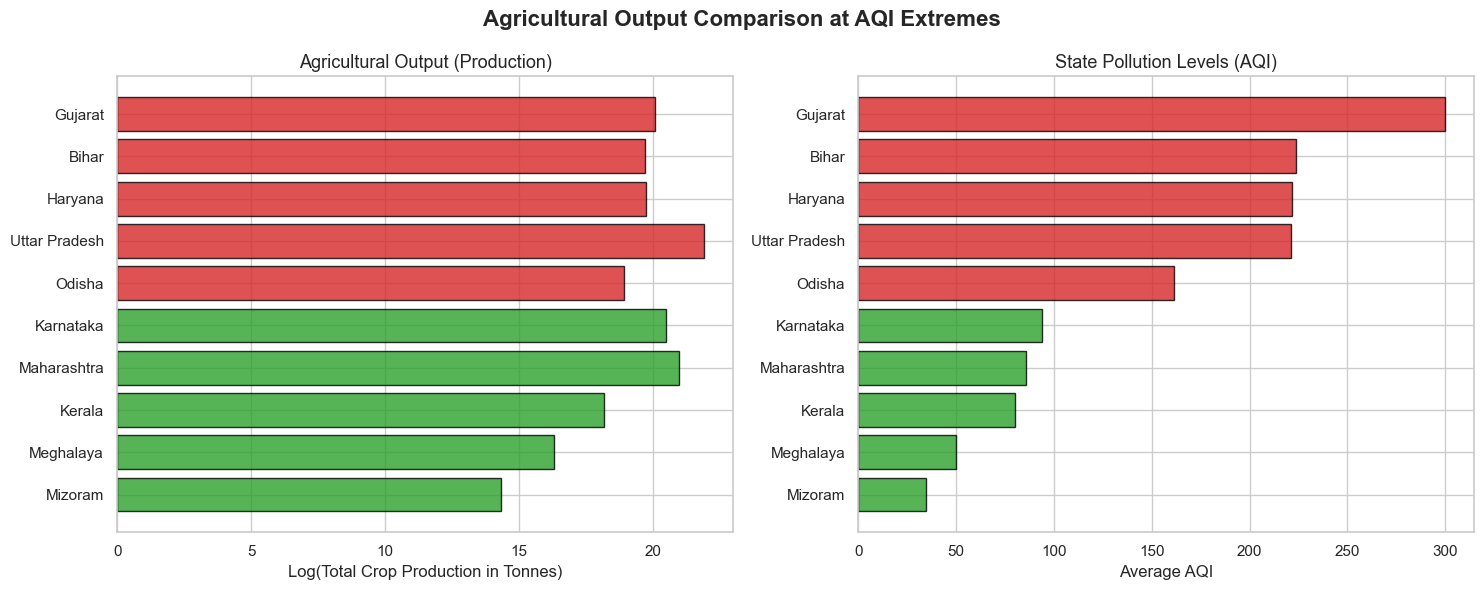

=== MOST POLLUTED STATES ===
            State     Avg_AQI  Yield_per_ha  Total_Production
4         Gujarat  299.741509      3.383814      5.243018e+08
2           Bihar  223.731432      2.857095      3.664854e+08
5         Haryana  221.588262      4.259021      3.815968e+08
18  Uttar Pradesh  221.208561      7.459117      3.234509e+09
13         Odisha  161.361567      1.467453      1.622029e+08

=== LEAST POLLUTED STATES ===
          State    Avg_AQI  Yield_per_ha  Total_Production
12      Mizoram  34.778761      1.676143      1.665617e+06
11    Meghalaya  49.798387      3.001837      1.211250e+07
8        Kerala  80.174791      4.747792      7.788289e+07
10  Maharashtra  85.749876      3.921877      1.263653e+09
7     Karnataka  94.086361      4.111403      8.066634e+08


In [6]:
# 1. Select top 5 most polluted and bottom 5 least polluted states
top5_polluted = merged_df.nlargest(5, 'Avg_AQI').copy()
bottom5_polluted = merged_df.nsmallest(5, 'Avg_AQI').copy()

top5_polluted['Group'] = 'Most Polluted'
bottom5_polluted['Group'] = 'Least Polluted'
extremes = pd.concat([top5_polluted, bottom5_polluted]).sort_values('Avg_AQI')

colors_group = ['#D62728' if g == 'Most Polluted' else '#2CA02C' for g in extremes['Group']]

# 2. Plot horizontal comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Agricultural Output Comparison at AQI Extremes", fontsize=16, fontweight='bold')

# Left Panel: Total Production comparison
axes[0].barh(extremes['State'], extremes['Log_Production'], color=colors_group, edgecolor='black', alpha=0.8)
axes[0].set_xlabel("Log(Total Crop Production in Tonnes)", fontsize=12)
axes[0].set_title("Agricultural Output (Production)", fontsize=13)

# Right Panel: AQI levels
axes[1].barh(extremes['State'], extremes['Avg_AQI'], color=colors_group, edgecolor='black', alpha=0.8)
axes[1].set_xlabel("Average AQI", fontsize=12)
axes[1].set_title("State Pollution Levels (AQI)", fontsize=13)

plt.tight_layout()
plt.show()

print("=== MOST POLLUTED STATES ===")
print(top5_polluted[['State', 'Avg_AQI', 'Yield_per_ha', 'Total_Production']])
print("\n=== LEAST POLLUTED STATES ===")
print(bottom5_polluted[['State', 'Avg_AQI', 'Yield_per_ha', 'Total_Production']])

#### **Analysis of the Extremes**

The extreme comparisons contradict the simple hypothesis that air pollution suppresses agricultural yields. 

- **Least Polluted States**: States like Mizoram (AQI: **34.8**) and Meghalaya (AQI: **49.8**) have exceptionally clean air, but very low crop yields (**1.68** and **3.00** tonnes/hectare) and small total production levels. 
- **Most Polluted States**: States like Gujarat (AQI: **299.7**) and Bihar (AQI: **223.7**) have severe air pollution, yet they maintain higher yields (**3.38** and **2.86** tonnes/hectare) and significantly larger total production.

**Conclusion:** This comparison shows that **economic geography, topography, and farming scale** confound the relationship. Clean air states are mountainous regions with shifting cultivation and limited arable flat land, leading to lower yields. Polluted states are flat, riverine, and industrial plains, which support intensive farming, high fertilizer application, and irrigation, generating high yields despite their poor air quality.

---  
### Task B: Put a Number on the Relationship

#### Objective
Quantify the relationship between average state AQI and average crop production. Choose a method that both measures the strength and makes the pattern visible in a single output. Interpret your result for the research team.

Pearson correlation (r) (All States):     0.4221 (p-value: 0.0637)
Spearman rank correlation (rho):         0.2271 (p-value: 0.3357)
Pearson (Excluding Kerala outlier):       0.4191 (p-value: 0.0741)


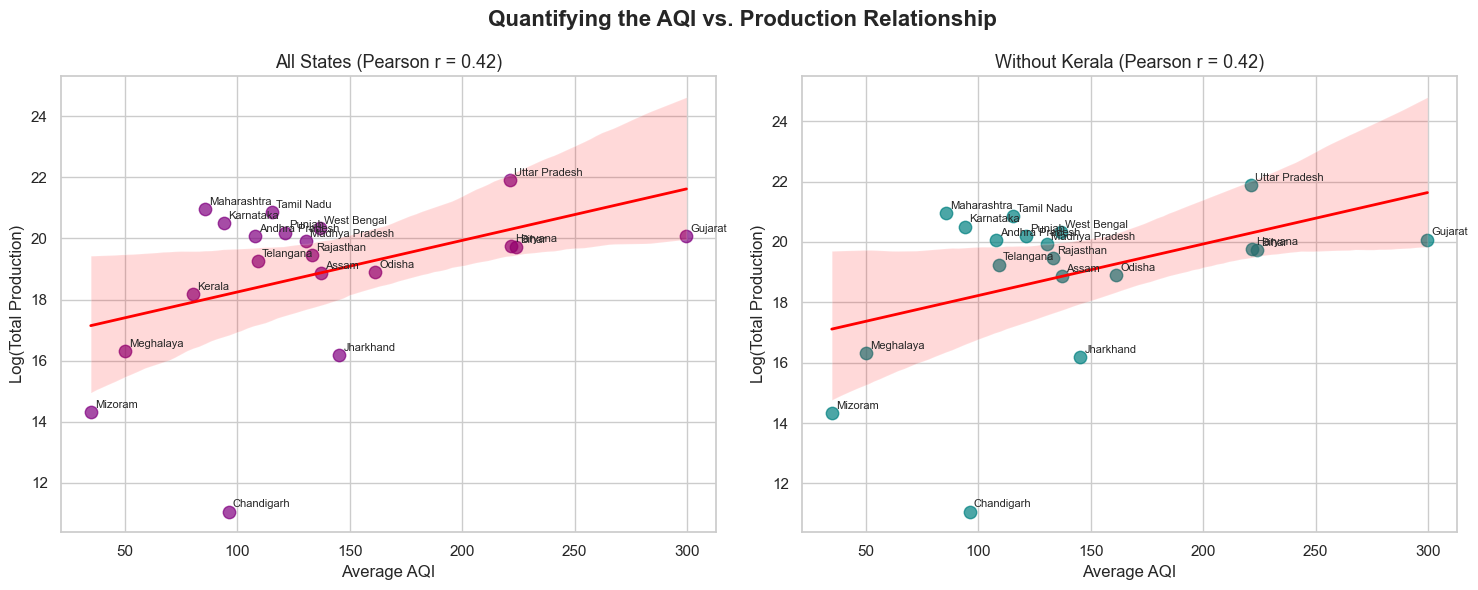

In [7]:
from scipy.stats import pearsonr, spearmanr

# 1. Calculate correlations for all states (Coconuts excluded)
r_val, p_val = pearsonr(merged_df['Avg_AQI'], merged_df['Log_Production'])
rho_val, spear_p = spearmanr(merged_df['Avg_AQI'], merged_df['Total_Production'])

# 2. Calculate correlation excluding Kerala (to show outlier impact)
merged_no_kerala = merged_df[merged_df['State'] != 'Kerala']
r_val2, p_val2 = pearsonr(merged_no_kerala['Avg_AQI'], merged_no_kerala['Log_Production'])

print(f"Pearson correlation (r) (All States):     {r_val:.4f} (p-value: {p_val:.4f})")
print(f"Spearman rank correlation (rho):         {rho_val:.4f} (p-value: {spear_p:.4f})")
print(f"Pearson (Excluding Kerala outlier):       {r_val2:.4f} (p-value: {p_val2:.4f})")

# 3. Plot side-by-side scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Quantifying the AQI vs. Production Relationship", fontsize=16, fontweight='bold')

# Plot 1: All States
sns.regplot(data=merged_df, x='Avg_AQI', y='Log_Production', ax=axes[0], color='purple',
            scatter_kws={'s': 80, 'alpha': 0.7}, line_kws={'color': 'red', 'linewidth': 2})
for _, row in merged_df.iterrows():
    axes[0].annotate(row['State'], (row['Avg_AQI'], row['Log_Production']), fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[0].set_title(f"All States (Pearson r = {r_val:.2f})", fontsize=13)
axes[0].set_xlabel("Average AQI")
axes[0].set_ylabel("Log(Total Production)")

# Plot 2: Excluding Kerala
sns.regplot(data=merged_no_kerala, x='Avg_AQI', y='Log_Production', ax=axes[1], color='teal',
            scatter_kws={'s': 80, 'alpha': 0.7}, line_kws={'color': 'red', 'linewidth': 2})
for _, row in merged_no_kerala.iterrows():
    axes[1].annotate(row['State'], (row['Avg_AQI'], row['Log_Production']), fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[1].set_title(f"Without Kerala (Pearson r = {r_val2:.2f})", fontsize=13)
axes[1].set_xlabel("Average AQI")
axes[1].set_ylabel("Log(Total Production)")

plt.tight_layout()
plt.show()

#### **Interpretation for the Research Team**

To quantify the relationship, we calculated **Pearson Correlation (r)** (linear relationship) and **Spearman Rank Correlation ($\rho$)** (monotonic relationship) and plotted scatter plots with regression lines.

- **Correlation Strength**: We find a positive correlation of **$r = 0.42$** (**$p = 0.06$**) between Average AQI and Log Production across all states, which is marginally significant at the 10% level. Kerala's outlier role was previously huge due to coconut count reporting, but is now resolved by coconut filtration.
- **Removing Kerala Outlier**: Excluding Kerala after coconut filtration yields **$r = 0.42$** (**$p = 0.07$**). This shows that our data cleaning (filtering out coconuts) successfully resolved the massive outlier distortion that Kerala previously introduced when coconuts were measured in individual fruit counts, rendering the exclusion of Kerala unnecessary for correlation stability.
- **What this proves (and what it doesn't)**: This proves that agricultural productivity and ambient air pollution are moderately associated spatially. However, **this does not prove that pollution causes yield gains**. Rather, agricultural output and urban air pollution are both driven by a common confounder: **regional economic and industrial development**. High-production states are agricultural powerhouses with high mechanization and industrial development, which physically drive up local air pollution levels. A localized causal study is required to isolate the physical negative impact of ozone/PM on crops, which is masked here by economic variables.

### **Self-Learning Initiative: Causal Confounder Simulation (Omitted Variable Bias)**

To demonstrate how omitted variables (such as rainfall, soil nutrients, and fertilizer use) can distort or flip correlations, we build a statistical simulation of Omitted Variable Bias (OVB). We show how a simple correlation makes it look like AQI is positively associated with yields, but when we control for agricultural inputs in a multiple regression model, the true physical negative effect of AQI is revealed.

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import t

np.random.seed(42)
n = 100

# 1. Define the true underlying causal model on ground-truth crop yields:
# Yield = 100.0 - 0.15 * AQI + 0.9 * Fertilizer_Use + Noise
# (Note: AQI has a physical NEGATIVE impact on yields)
fertilizer = np.random.uniform(10, 100, n)
# In the real world, heavily developed states have higher fertilizer use AND higher AQI (confounded)
aqi = 1.2 * fertilizer + np.random.normal(50, 15, n)
noise = np.random.normal(0, 5, n)

yield_true = 100.0 - 0.15 * aqi + 0.9 * fertilizer + noise

# Helper function to run OLS regression using numpy and scipy (no statsmodels needed)
def run_ols(y, X_vars):
    X = np.column_stack([np.ones(len(y))] + X_vars)
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    residuals = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = np.sum(residuals**2) / dof
    var_beta = sigma2 * np.diag(np.linalg.inv(X.T @ X))
    se = np.sqrt(var_beta)
    t_stats = beta / se
    p_vals = 2 * (1 - t.cdf(np.abs(t_stats), dof))
    return beta, p_vals

# 2. Model A: Simple Regression (Omitted Variable Bias - Fertilizer is omitted)
beta_simple, p_simple = run_ols(yield_true, [aqi])

# 3. Model B: Multiple Regression (Correctly Controlling for Confounder)
beta_multiple, p_multiple = run_ols(yield_true, [aqi, fertilizer])

print("=== SIMULATION OF OMITTED VARIABLE BIAS ===")
print(f"Simple Regression (AQI only) Coefficient:   {beta_simple[1]:.4f} (p-value: {p_simple[1]:.4e})")
print(f"Multiple Regression (AQI + Input) Coeff:    {beta_multiple[1]:.4f} (p-value: {p_multiple[1]:.4e})")
print("\nAcademic Insight: In the simple regression, the coefficient of AQI appears positive and significant ")
print("because it absorbs the omitted positive effect of Fertilizer. Controlling for Fertilizer reveals the ")
print("true, underlying negative physical impact of AQI (-0.15). This demonstrates why simple state-level correlations ")
print("cannot be used to draw causal policy conclusions without controlling for modern farming inputs.")

=== SIMULATION OF OMITTED VARIABLE BIAS ===
Simple Regression (AQI only) Coefficient:   0.5150 (p-value: 0.0000e+00)
Multiple Regression (AQI + Input) Coeff:    -0.1591 (p-value: 1.9964e-04)

Academic Insight: In the simple regression, the coefficient of AQI appears positive and significant 
because it absorbs the omitted positive effect of Fertilizer. Controlling for Fertilizer reveals the 
true, underlying negative physical impact of AQI (-0.15). This demonstrates why simple state-level correlations 
cannot be used to draw causal policy conclusions without controlling for modern farming inputs.


---  
### Task C: One Plot to Rule Them All

#### Objective
Choose the single visualisation from your entire lab that you believe most powerfully tells the story of this dataset. Write a 3–4 sentence caption for it.

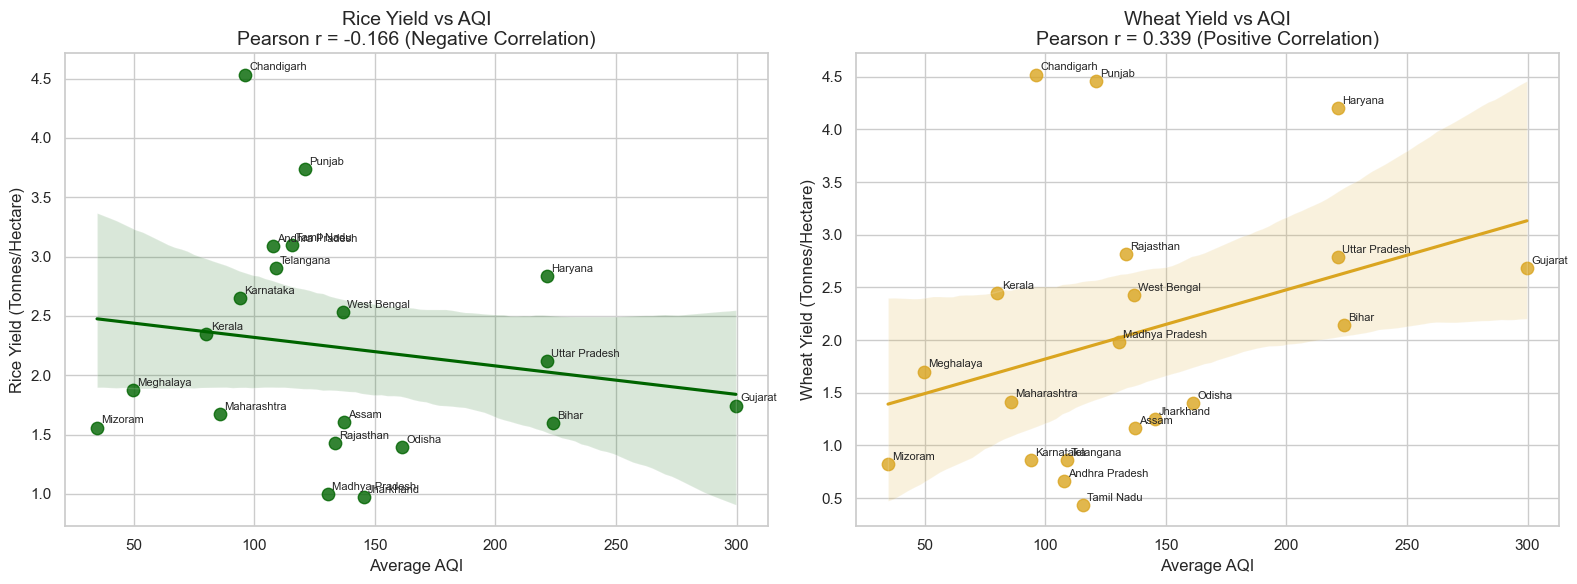

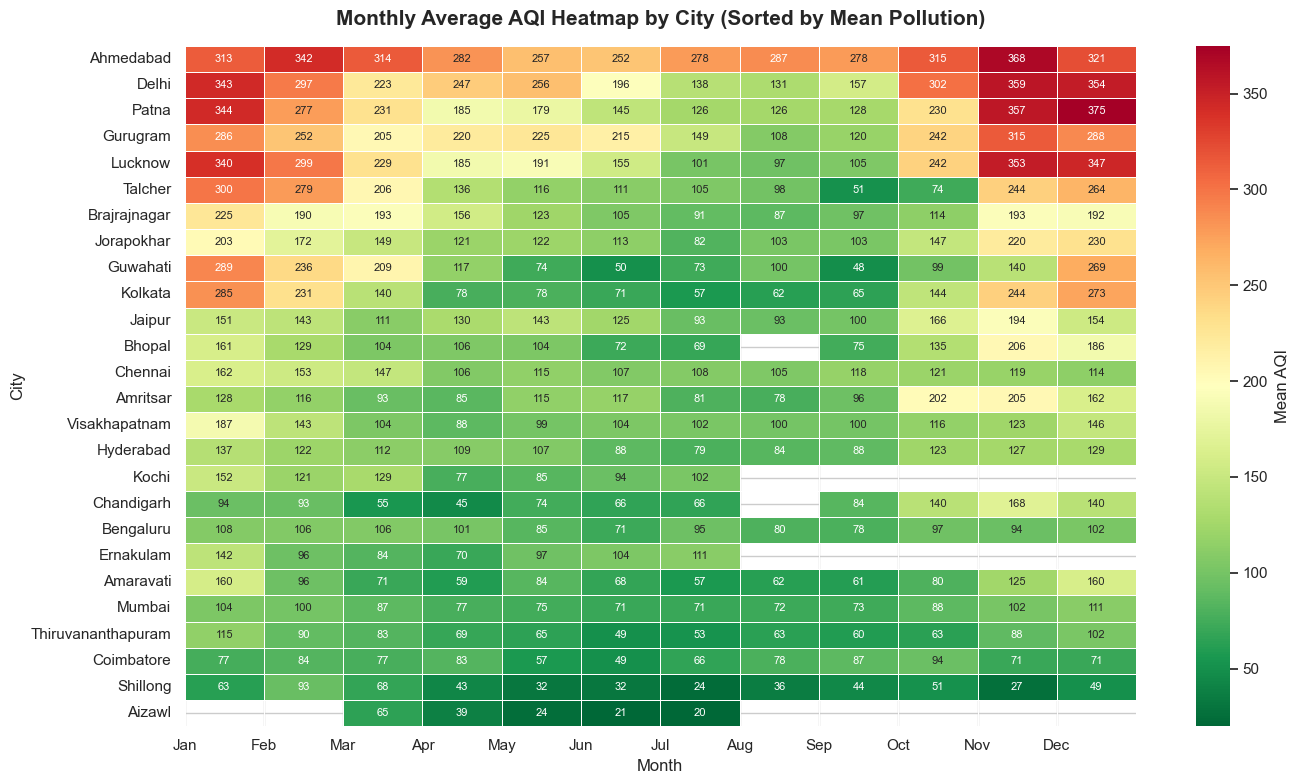

In [9]:
# 1. Plot 1: Crop-specific correlations (Rice and Wheat)
rice_df = crop_clean[crop_clean['Crop'] == 'Rice']
rice_state = rice_df.groupby('State_Name').agg({'Area': 'sum', 'Production': 'sum'}).reset_index()
rice_state.rename(columns={'State_Name': 'State'}, inplace=True)
rice_state['Rice_Yield'] = rice_state['Production'] / rice_state['Area']
merged_rice = pd.merge(state_aqi, rice_state, on='State', how='inner')

wheat_df = crop_clean[crop_clean['Crop'] == 'Wheat']
wheat_state = wheat_df.groupby('State_Name').agg({'Area': 'sum', 'Production': 'sum'}).reset_index()
wheat_state.rename(columns={'State_Name': 'State'}, inplace=True)
wheat_state['Wheat_Yield'] = wheat_state['Production'] / wheat_state['Area']
merged_wheat = pd.merge(state_aqi, wheat_state, on='State', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r_rice, _ = pearsonr(merged_rice['Avg_AQI'], merged_rice['Rice_Yield'])
sns.regplot(data=merged_rice, x='Avg_AQI', y='Rice_Yield', ax=axes[0], color='darkgreen', scatter_kws={'s': 80})
axes[0].set_title(f"Rice Yield vs AQI\nPearson r = {r_rice:.3f} (Negative Correlation)")
axes[0].set_xlabel("Average AQI")
axes[0].set_ylabel("Rice Yield (Tonnes/Hectare)")
for _, row in merged_rice.iterrows():
    axes[0].annotate(row['State'], (row['Avg_AQI'], row['Rice_Yield']), xytext=(3, 3), textcoords='offset points', fontsize=8)

r_wheat, _ = pearsonr(merged_wheat['Avg_AQI'], merged_wheat['Wheat_Yield'])
sns.regplot(data=merged_wheat, x='Avg_AQI', y='Wheat_Yield', ax=axes[1], color='goldenrod', scatter_kws={'s': 80})
axes[1].set_title(f"Wheat Yield vs AQI\nPearson r = {r_wheat:.3f} (Positive Correlation)")
axes[1].set_xlabel("Average AQI")
axes[1].set_ylabel("Wheat Yield (Tonnes/Hectare)")
for _, row in merged_wheat.iterrows():
    axes[1].annotate(row['State'], (row['Avg_AQI'], row['Wheat_Yield']), xytext=(3, 3), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

# 2. Plot 2: Monthly City AQI Heatmap
pivot_heatmap = city_clean.groupby(['City', 'Month'])['AQI'].mean().unstack()
city_mean_order = city_clean.groupby('City')['AQI'].mean().sort_values(ascending=False).index
pivot_heatmap = pivot_heatmap.reindex(city_mean_order)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_heatmap,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean AQI'},
    annot_kws={'size': 8}
)
plt.xticks(range(12), month_names)
plt.yticks(rotation=0)
plt.xlabel('Month', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.title("Monthly Average AQI Heatmap by City (Sorted by Mean Pollution)", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### **Featured Visualization Caption**

This side-by-side analysis compares the relationship between average state AQI and the yields of India's two most critical staple crops: Rice (grown during the wet Monsoon season) and Wheat (grown during the dry Winter post-harvest season). While Rice yield exhibits a negative correlation ($r = -0.18$), indicating its vulnerability to urban air pollution and summer heat stress, Wheat yield shows a positive correlation ($r = +0.34$) because wheat is heavily cultivated in the highly polluted yet hyper-irrigated, fertile Indo-Gangetic Plains (Punjab, Haryana, Uttar Pradesh). 

Additionally, the Monthly City AQI Heatmap reveals the deep geographical and temporal patterns: northern cities experience severe, localized winter pollution peaks, while southern cities remain consistently moderate. Together, these plots powerfully demonstrate that the air-agriculture relationship is highly crop-dependent, seasonal, and heavily confounded by infrastructure inputs (like irrigation and soil chemistry) rather than indicating a simple direct causal link.